# Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import KNNImputer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, BatchNormalization, concatenate
from tensorflow.keras.callbacks import EarlyStopping

# Loading DataSet

In [2]:
df = pd.read_csv("datasets/boston_housing.csv")
print(f"Dataset loaded to dataframe df having dimensions {df.shape}")

Dataset loaded to dataframe df having dimensions (506, 14)


# Exploring Dataset

## Size and Dimensions

In [3]:
print(f"No. of Rows : {df.shape[0]}\nNo. of Columns : {df.shape[1]}\nTotal No. of Cells : {df.size}")

No. of Rows : 506
No. of Columns : 14
Total No. of Cells : 7084


## Displaying Sample Rows

In [4]:
print("Top 5 rows")
display(df.head())

Top 5 rows


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
print("Last 5 rows")
display(df.tail())

Last 5 rows


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


In [6]:
print("Randomly selected 5 rows")
display(df.sample(5))

Randomly selected 5 rows


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
47,0.22927,0.0,6.91,0,0.448,6.030,85.5,5.6894,3,233,17.9,392.74,18.80,16.6
270,0.29916,20.0,6.96,0,0.464,5.856,42.1,4.4290,3,223,18.6,388.65,13.00,21.1
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
94,0.04294,28.0,15.04,0,0.464,6.249,77.3,3.6150,4,270,18.2,396.90,10.59,20.6
163,1.51902,0.0,19.58,1,0.605,8.375,93.9,2.1620,5,403,14.7,388.45,3.32,50.0


## Metadata

In [7]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


None

## Statistical Summary

In [8]:
display(df.describe())

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


# EDA

## Missing Values Analysis

In [9]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [10]:
print(f"Missing Values per Field\n{(df.isnull().sum() / len(df)) * 100}")

Missing Values per Field
CRIM       0.0
ZN         0.0
INDUS      0.0
CHAS       0.0
NOX        0.0
RM         0.0
AGE        0.0
DIS        0.0
RAD        0.0
TAX        0.0
PTRATIO    0.0
B          0.0
LSTAT      0.0
MEDV       0.0
dtype: float64


## Target Variable Distribution (MEDV)

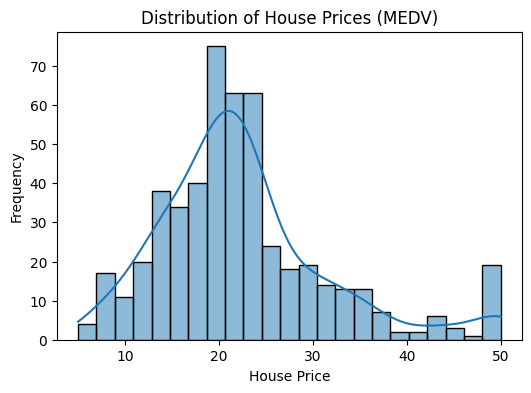

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.histplot(df["MEDV"], kde=True)
plt.title("Distribution of House Prices (MEDV)")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.show()

## Box Plot of Target Variable

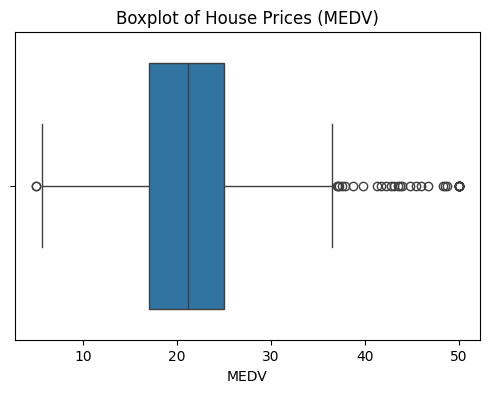

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["MEDV"])
plt.title("Boxplot of House Prices (MEDV)")
plt.show()

## Avg No. of Rooms v/s MEDV

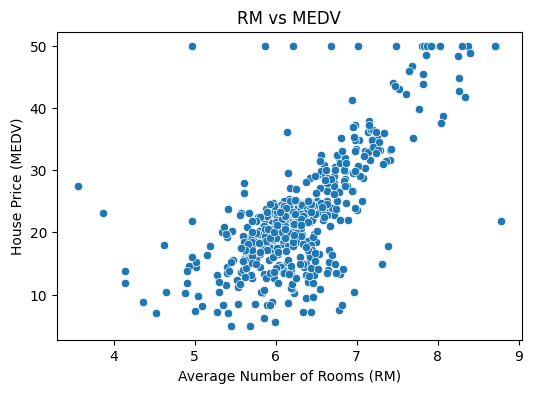

In [13]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["RM"], y=df["MEDV"])
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("House Price (MEDV)")
plt.title("RM vs MEDV")
plt.show()

## Correlation HeatMap

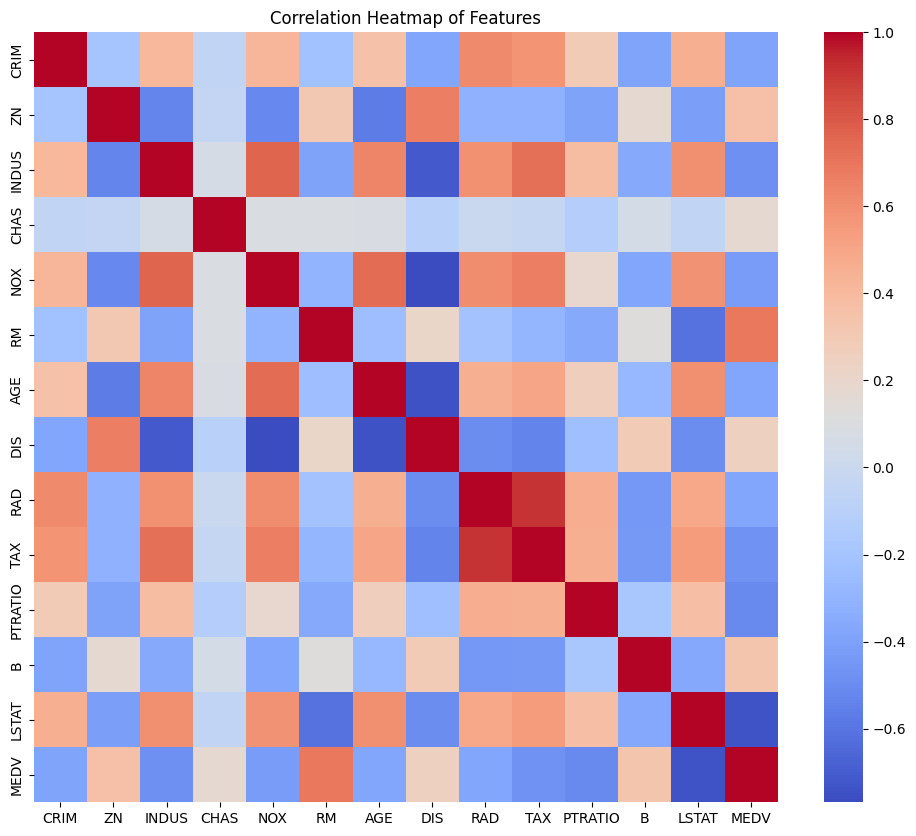

In [14]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Features")
plt.show()

# Data Preprocessing

## Preserving Raw DataSet

In [15]:
df_pre = df.copy()

## Eliminating Outliers

In [16]:
Q1 = df["MEDV"].quantile(0.25)
Q3 = df["MEDV"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df["MEDV"] >= lower_bound) & (df["MEDV"] <= upper_bound)]

In [17]:
# from scipy import stats
# import numpy as np

# df_no_outliers = df[(np.abs(stats.zscore(df["MEDV"])) < 3)]

In [18]:
df_no_outliers.size

6524

In [19]:
# plt.figure(figsize=(6,4))
# sns.boxplot(x=df["MEDV"])
# plt.title("Boxplot of House Prices (MEDV)")
# plt.show()

## Separate Features and Target

In [20]:
X = df_no_outliers.drop("MEDV", axis=1)
y = df_no_outliers["MEDV"]

## Split the DataSet

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Handling Missing Values

### KNN Imputation

In [23]:
# from sklearn.impute import KNNImputer

# imputer = KNNImputer(
#     n_neighbors=5,
#     weights="distance"
# )

# X_train_imputed = imputer.fit_transform(X_train_scaled)
# X_test_imputed = imputer.transform(X_test_scaled)

In [24]:
import numpy as np

print("Missing values in training data:", np.isnan(X_train_scaled).sum())
print("Missing values in test data:", np.isnan(X_test_scaled).sum())

Missing values in training data: 0
Missing values in test data: 0


### Split Details

In [25]:
print("Training data shape:", X_train_scaled.shape)
print("Test data shape:", X_test_scaled.shape)

Training data shape: (372, 13)
Test data shape: (94, 13)


### Convert imputed arrays to DataFrames

In [26]:
X_train_imputed = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_imputed = pd.DataFrame(X_test_scaled, columns=X.columns)

## DataTypes Compatibility

In [27]:
df.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

# Model Architecture

In [28]:
from tensorflow import keras
from tensorflow.keras import layers

def build_simpler_model():
    inputs = keras.Input(shape=(X_train_imputed.shape[1],))
    
    # Optional: normalize inputs
    x = layers.BatchNormalization()(inputs)
    
    # Two hidden layers with dropout
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    
    # Output layer
    output = layers.Dense(1)(x)
    
    model = keras.Model(inputs=inputs, outputs=output)
    return model

# Instantiate and compile
model = build_simpler_model()
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 13)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 13)                  │              52 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,061 (11.96 KB)

 Trainable params: 3,035 (11.86 KB)

 Non-trainable params: 26 (104.00 B)

In [29]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train the Model

In [30]:
history = model.fit(
    X_train_imputed,
    y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 485.6624 - mae: 20.9923 - val_loss: 400.3627 - val_mae: 19.0240
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 428.2440 - mae: 19.6860 - val_loss: 339.9407 - val_mae: 17.3865
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 360.8307 - mae: 17.8260 - val_loss: 248.1726 - val_mae: 14.6616
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 252.4641 - mae: 14.5233 - val_loss: 133.8812 - val_mae: 10.2851
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 142.9149 - mae: 10.2780 - val_loss: 57.5451 - val_mae: 6.1314
Epoch 6/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 65.7265 - mae: 6.6795 - val_loss: 37.9079 - val_mae: 4.9747
Epoch 7/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 59.2828 - mae: 6.0101 - val_loss: 27.7959 - val_mae: 4.2333
Epoch 8/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 47.4448 - mae: 5.4107 - val_loss: 20.4052 - val_mae: 3.6162
Epoch 9/200
19/19 ━━━━━━━━━━━

# Plot Training & Validation Loss

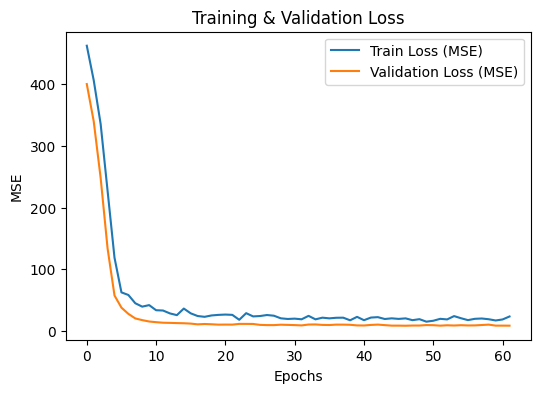

In [31]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('Training & Validation Loss')
plt.legend()
plt.show()

# Evaluation

In [32]:
y_pred = model.predict(X_test_imputed)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Test Mean Squared Error (MSE):", mse)
print("Test Mean Absolute Error (MAE):", mae)
print("Test R² Score:", r2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Test Mean Squared Error (MSE): 6.862205918556502
Test Mean Absolute Error (MAE): 2.0144117598837994
Test R² Score: 0.8289386185067738


## Actual v/s Predicted Price

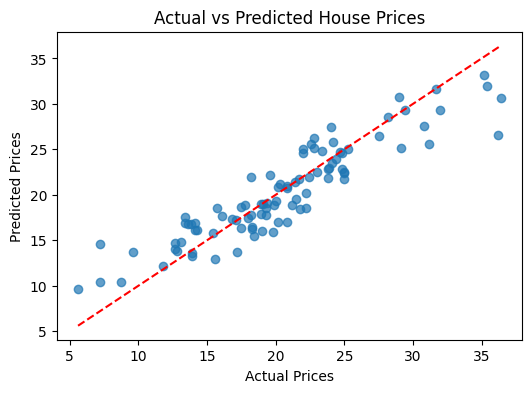

In [33]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45° line
plt.show()